In [2]:
import os
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import astropy.units as u
import astropy.io.fits as fits

# Load data image and header

In [13]:
data_dir = os.getcwd()
files_roll1 = [f for f in os.listdir(data_dir) if f.startswith("host_star_image_roll1")]
files_roll2 = [f for f in os.listdir(data_dir) if f.startswith("host_star_image_roll2")]
print(files_roll1)
print(files_roll2)

roll1 = []
for file in files_roll1:
    roll1.append(fits.getdata(file))
roll1 = np.array(roll1)

roll2 = []
for file in files_roll2:
    roll2.append(fits.getdata(file))
roll2 = np.array(roll2)

['host_star_image_roll1_0.fits']
['host_star_image_roll2_0.fits']


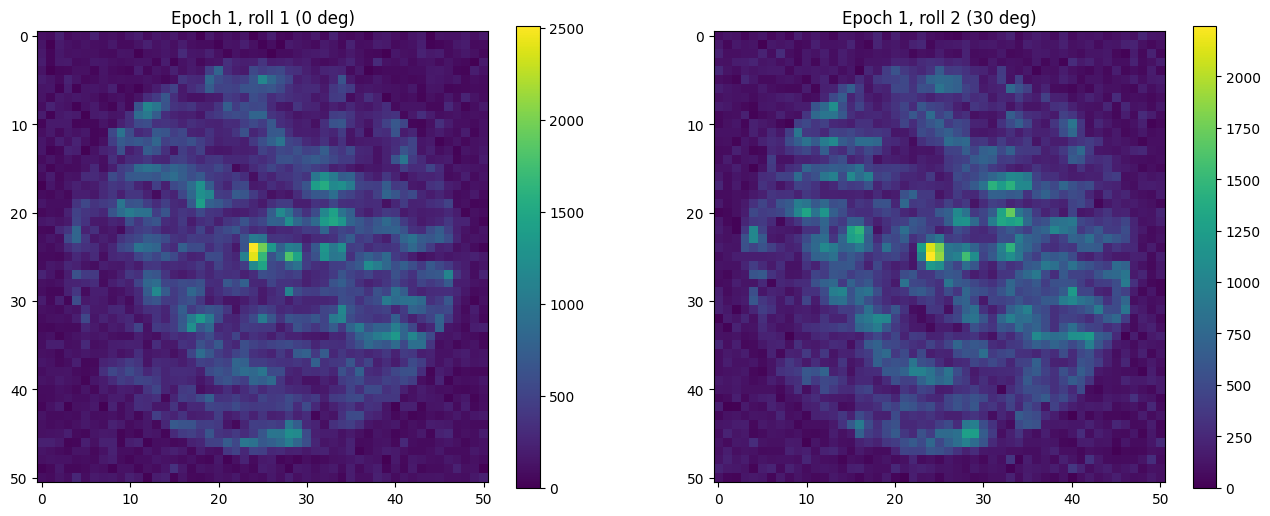

In [14]:
coadd_roll1 = np.mean(roll1, axis = 0)
coadd_roll2 = np.mean(roll2, axis = 0)

plt.figure(figsize=(16,6))

plt.subplot(121)
plt.imshow(coadd_roll1)
plt.title('Epoch 1, roll 1 (0 deg)')
plt.colorbar()

plt.subplot(122)
plt.title('Epoch 1, roll 2 (30 deg)')
plt.imshow(coadd_roll2)
plt.colorbar()

# Roll subtraction and roll combination

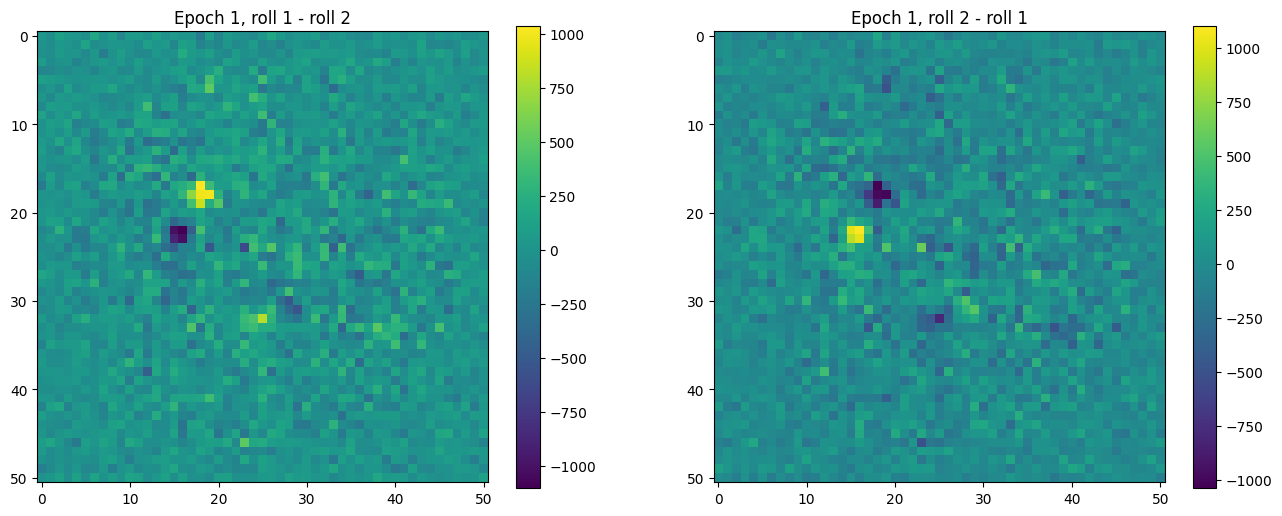

In [15]:
diff1 = coadd_roll1 - coadd_roll2
diff2 = coadd_roll2 - coadd_roll1

plt.figure(figsize=(16,6))

plt.subplot(121)
plt.imshow(diff1)
plt.title('Epoch 1, roll 1 - roll 2')
plt.colorbar()

plt.subplot(122)
plt.title('Epoch 1, roll 2 - roll 1')
plt.imshow(diff2)
plt.colorbar()

In [16]:
import skimage.transform
scistar_coadd_ep1_rolls = [0, 30]
imgwidth = diff2.shape[0]
derot_diff_2 = skimage.transform.rotate(image = diff2,
                                        angle = -scistar_coadd_ep1_rolls[1],
                                        center = (imgwidth // 2, imgwidth // 2),
                                        order = 3, cval = np.nan)
derot_sum = diff1 + derot_diff_2

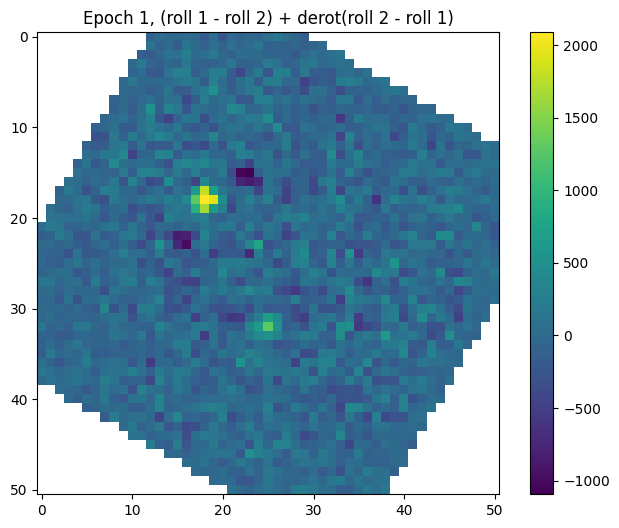

In [17]:
plt.figure(figsize=(8,6))

plt.imshow(derot_sum)

plt.title('Epoch 1, (roll 1 - roll 2) + derot(roll 2 - roll 1)')
plt.colorbar()

## Question 1: How would you estimate the signal-to-noise ratio of this source?

# Reference Differential Imaging

['ref_star_image_0.fits']


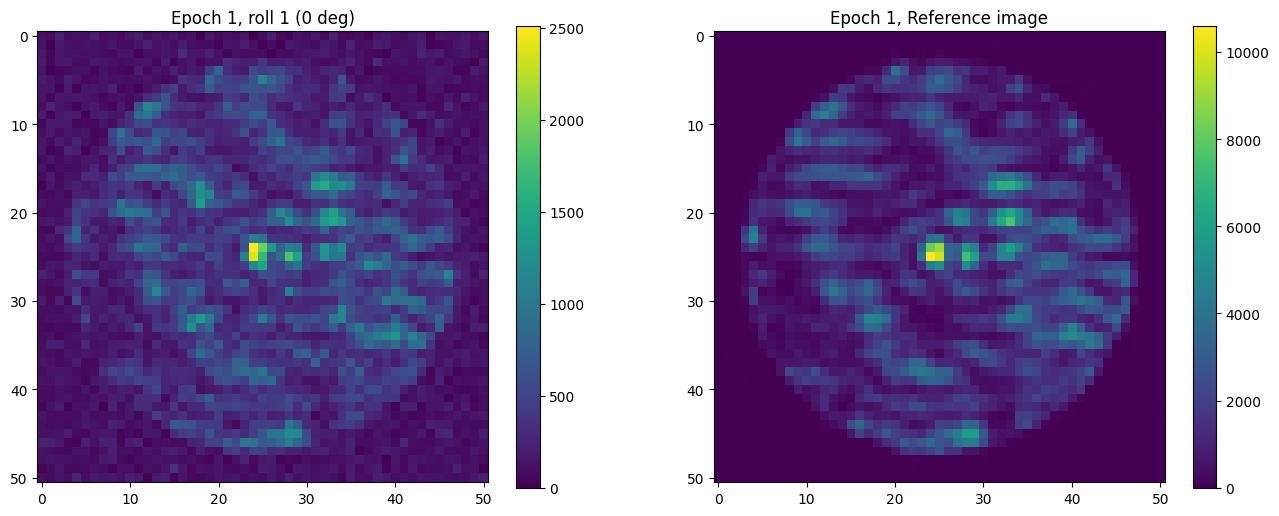

In [20]:
data_dir = os.getcwd()
files_ref = [f for f in os.listdir(data_dir) if f.startswith("ref_star_image")]
print(files_ref)


ref = []
for file in files_ref:
    ref.append(fits.getdata(file))
ref = np.array(ref)

coadd_ref = np.mean(ref, axis = 0)

plt.figure(figsize=(16,6))

plt.subplot(121)
plt.imshow(coadd_roll1)
plt.title('Epoch 1, roll 1 (0 deg)')
plt.colorbar()

plt.subplot(122)
plt.title('Epoch 1, Reference image')
plt.imshow(coadd_ref)
plt.colorbar()


In [25]:
count_sum_ratio_roll1 = (np.sum(coadd_ref)
                    / np.sum(coadd_roll1))
count_sum_ratio_roll2 = (np.sum(coadd_ref)
                    / np.sum(coadd_roll2))
print(count_sum_ratio_roll1)
print(count_sum_ratio_roll2)

2.9446029568440872
2.9685687661692763


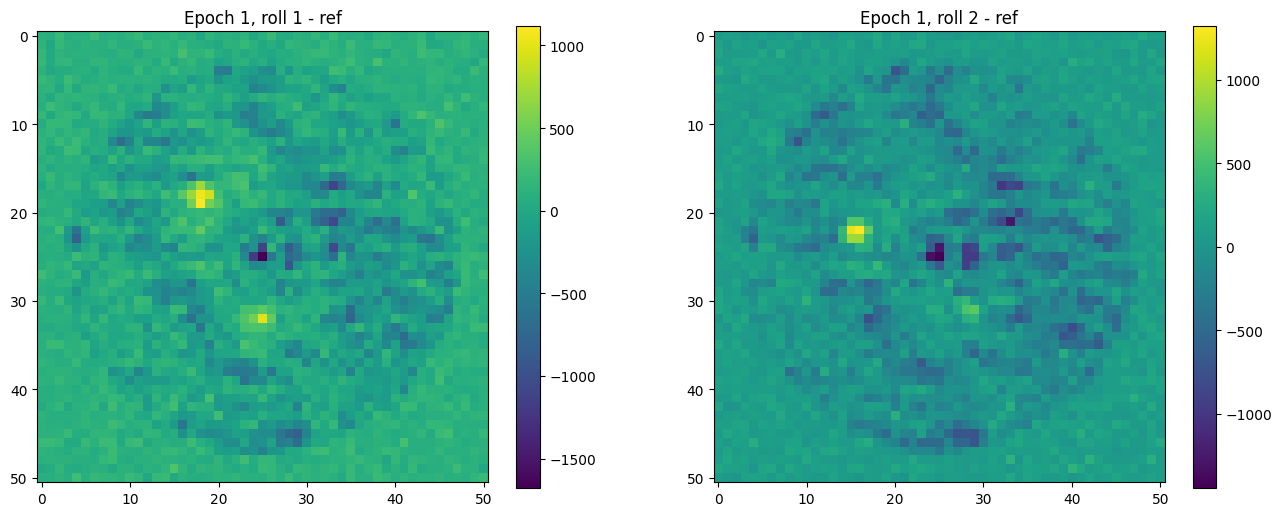

In [28]:
crude_rdi_result_roll1 = (coadd_roll1
                    - coadd_ref / count_sum_ratio_roll1)
crude_rdi_result_roll2 = (coadd_roll2
                    - coadd_ref / count_sum_ratio_roll2)

plt.figure(figsize=(16,6))

plt.subplot(121)
plt.imshow(crude_rdi_result_roll1)
plt.title('Epoch 1, roll 1 - ref')
plt.colorbar()

plt.subplot(122)
plt.title('Epoch 1, roll 2 - ref')
plt.imshow(crude_rdi_result_roll2)
plt.colorbar()

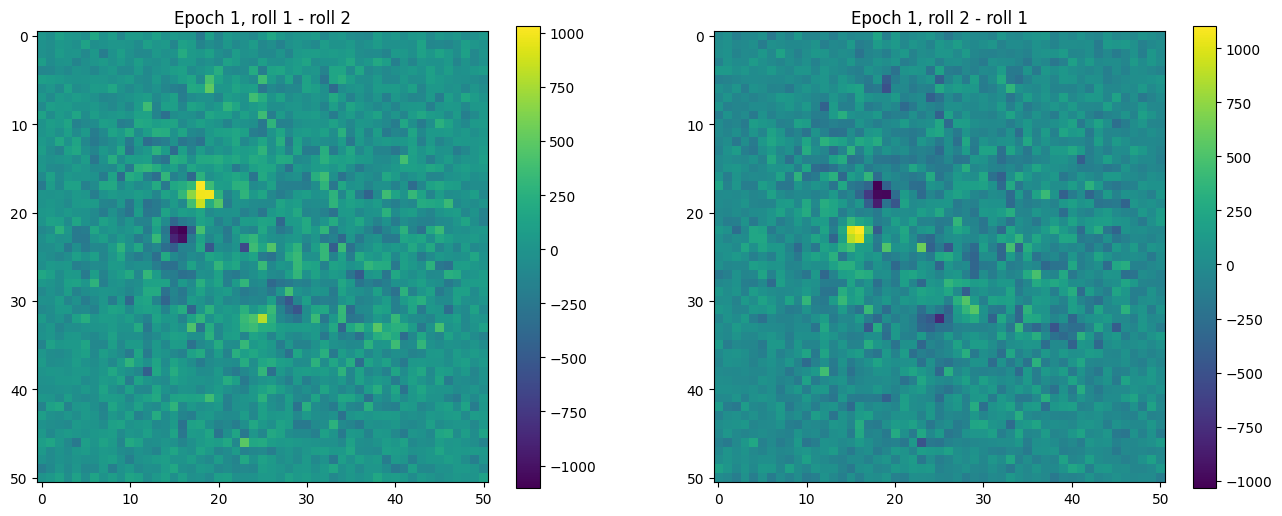

In [29]:
adi_rdi_1 = crude_rdi_result_roll1 - crude_rdi_result_roll2
adi_rdi_2 = crude_rdi_result_roll2 - crude_rdi_result_roll1

plt.figure(figsize=(16,6))

plt.subplot(121)
plt.imshow(adi_rdi_1)
plt.title('Epoch 1, roll 1 - roll 2')
plt.colorbar()

plt.subplot(122)
plt.title('Epoch 1, roll 2 - roll 1')
plt.imshow(adi_rdi_2)
plt.colorbar()

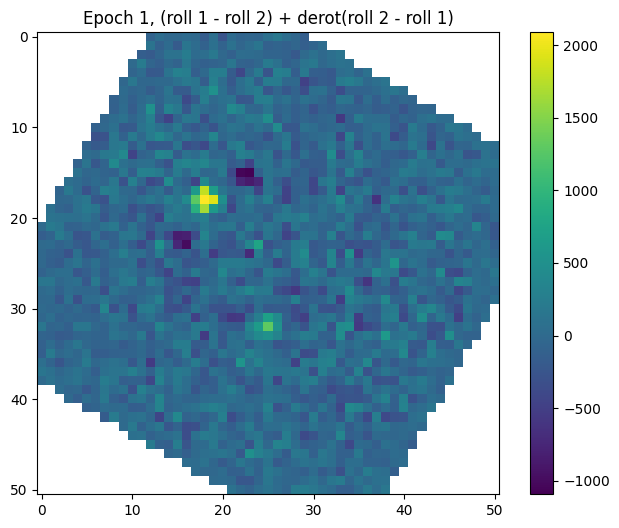

In [30]:
cistar_coadd_ep1_rolls = [0, 30]
imgwidth = diff2.shape[0]
derot_adi_rdi_2 = skimage.transform.rotate(image = adi_rdi_2,
                                        angle = -scistar_coadd_ep1_rolls[1],
                                        center = (imgwidth // 2, imgwidth // 2),
                                        order = 3, cval = np.nan)
derot_sum_adi_rdi = adi_rdi_1 + derot_adi_rdi_2

plt.figure(figsize=(8,6))

plt.imshow(derot_sum_adi_rdi)

plt.title('Epoch 1, (roll 1 - roll 2) + derot(roll 2 - roll 1)')
plt.colorbar()


Peak col = 18, peak row = 18
Sum in 3 x 3 box = 6253.96 electron


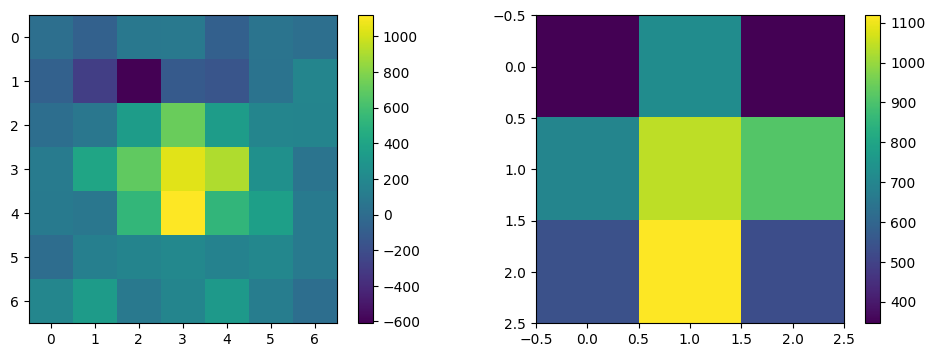

In [71]:
# Photometry
processed_image = crude_rdi_result_roll1
img_width = processed_image.shape[0]
phot_box_width = 3

src_peak_row = np.nanargmax(np.ravel(processed_image)) // img_width -1
src_peak_col = np.nanargmax(np.ravel(processed_image)) % img_width

phot_box_sum = np.sum(processed_image[src_peak_row - phot_box_width // 2 : 
                                    src_peak_row + phot_box_width // 2 + 1,
                                    src_peak_col - phot_box_width // 2 : 
                                    src_peak_col + phot_box_width // 2 + 1]) * u.electron

print("Peak col = {:d}, peak row = {:d}".format(src_peak_col, src_peak_row))
print("Sum in {:d} x {:d} box = {:.2f}".format(phot_box_width, phot_box_width, phot_box_sum))

plt.figure(figsize=(12, 4))

plt.subplot(121)
plot_box_width = 7
plt.imshow(processed_image[src_peak_row - plot_box_width // 2 : 
                         src_peak_row + plot_box_width // 2 + 1,
                         src_peak_col - plot_box_width // 2 : 
                         src_peak_col + plot_box_width // 2 + 1])
_ = plt.colorbar()

plt.subplot(122)
plt.imshow(processed_image[src_peak_row - phot_box_width // 2 : 
                         src_peak_row + phot_box_width // 2 + 1,
                         src_peak_col - phot_box_width // 2 : 
                         src_peak_col + phot_box_width // 2 + 1])
_ = plt.colorbar()

B.g. estimate = -75.177 electron
B.g.-subtracted aperture sum = 6930.557 electron


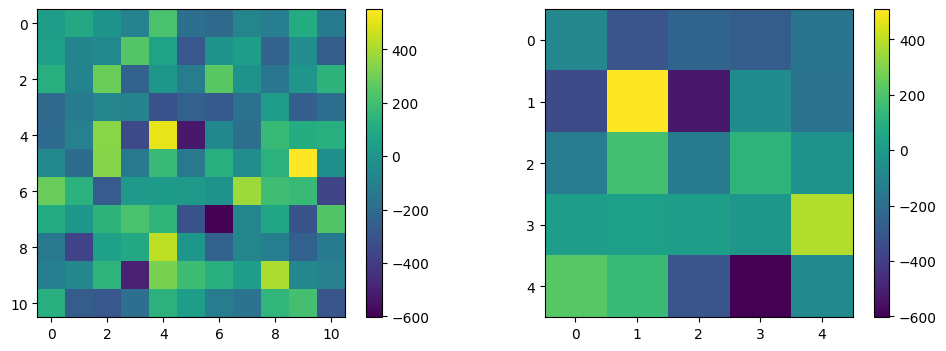

In [72]:
# Estimate the background count rate by taking a box away from the source, but at a similar angular separation from the star
bg_samp_col = 35
bg_samp_row = 25
bg_box_width = 5
bg_est = np.median(derot_sum_adi_rdi[bg_samp_row - bg_box_width//2 : 
                                 bg_samp_row + bg_box_width // 2 + 1,
                                 bg_samp_col - bg_box_width//2 : 
                                 bg_samp_col + bg_box_width // 2 + 1]) * u.electron

phot_box_sum_bgsub = phot_box_sum - bg_est * (phot_box_width * phot_box_width)

print("B.g. estimate = {:.3f}".format(bg_est))
print("B.g.-subtracted aperture sum = {:.3f}".format(phot_box_sum_bgsub))

plt.figure(figsize=(12, 4))

plt.subplot(121)
plot_box_width = 10
plt.imshow(derot_sum_adi_rdi[bg_samp_row - plot_box_width//2 : 
                         bg_samp_row + plot_box_width // 2 + 1,
                         bg_samp_col - plot_box_width//2 : 
                         bg_samp_col + plot_box_width // 2 + 1])
_ = plt.colorbar()

plt.subplot(122)
plt.imshow(derot_sum_adi_rdi[bg_samp_row - bg_box_width//2 : 
                         bg_samp_row + bg_box_width // 2 + 1,
                         bg_samp_col - bg_box_width//2 : 
                         bg_samp_col + bg_box_width // 2 + 1])
_ = plt.colorbar()

['host_star_PSF_0.fits']
25 25
Peak col = 25, peak row = 25
Star PSF photon count rate in 3 x 3 box = 48767.00 ph / s


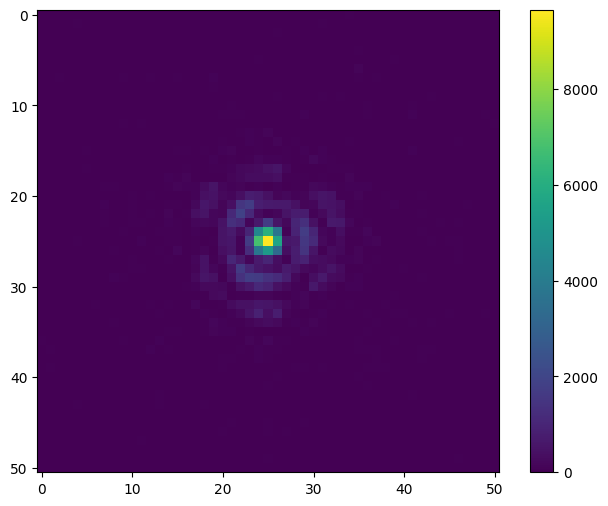

In [73]:
# Measure the star PSF model count rate in the same 3x3 box

data_dir = os.getcwd()
files_PSF = [f for f in os.listdir(data_dir) if f.startswith("host_star_PSF")]
print(files_PSF)


PSF = []
for file in files_PSF:
    PSF.append(fits.getdata(file))
PSF = np.array(PSF)

host_star_PSF = np.mean(PSF, axis = 0)

host_star_PSF_width = host_star_PSF.shape[0]

star_peak_row = np.nanargmax(np.ravel(host_star_PSF)) // host_star_PSF_width
star_peak_col = np.nanargmax(np.ravel(host_star_PSF)) % host_star_PSF_width
print(star_peak_col, star_peak_row)

star_phot_box_sum = (np.sum(host_star_PSF[star_peak_row - phot_box_width//2 : 
                                         star_peak_row + phot_box_width // 2 + 1,
                                         star_peak_col - phot_box_width//2 : 
                                         star_peak_col + phot_box_width // 2 + 1])
                     * u.photon / u.second)

print("Peak col = {:d}, peak row = {:d}".format(star_peak_col, star_peak_row))
print("Star PSF photon count rate in {:d} x {:d} box = {:.2f}".format(
      phot_box_width, phot_box_width, star_phot_box_sum))

plt.figure(figsize=(8, 6))
plt.imshow(host_star_PSF)
plt.colorbar()

In [79]:
planet_phot_box_sum = (phot_box_sum / 1)/ u.electron * u.photon / u.second#(det_qe * pc_loss * psf_atten)) / tot_inttime
print("Planet PSF photon count rate in {:d} x {:d} box = {:.2E}".format(
      phot_box_width, phot_box_width, planet_phot_box_sum))

planet_flux_ratio = (planet_phot_box_sum / 10000) / (star_phot_box_sum / 0.01)  /0.9
print("Measured planet flux ratio = {:.3E}".format(planet_flux_ratio))

true_flux_ratio = 10**((8-25)/2.5)  # taken from scene simulation inputs
error_frac = (planet_flux_ratio - true_flux_ratio) / true_flux_ratio
print("Measured flux ratio = {:.2E}\nTrue flux ratio = {:.2E}\nRelative error = {:.1f}%".format(
      planet_flux_ratio, true_flux_ratio, 100 * error_frac))

Planet PSF photon count rate in 3 x 3 box = 6.25E+03 ph / s
Measured planet flux ratio = 1.425E-07
Measured flux ratio = 1.42E-07
True flux ratio = 1.58E-07
Relative error = -10.1%


In [ ]:
# TARGET STAR PROCESSING
# BY THE BOOK : 
# data_1 = -np.log ( 1 - data_1 / ( numfrm * np.exp ( - n_thresholdfactor * sigma_readnoise / gain_trg ) ) )
# data_1        will be called "nobs"          in Nemati equations
# numfrm        will be called "nfr"           in Nemati equations
# tau_threshold will be called "threshold" (t) in Nemati equations
# gain_trg      will be called "gain"      (g) in Nemati equations
# The following steps were performed for each pointing of each
#   noisy target data cube at both -11 degrees and +11 degrees:
# • Apply threshold to each frame of data cube. We chose a threshold factor of 5 
#   (5 times read noise, note that read noise can be found in the FITS header) 
#   in this case. Binary images were obtained in output;
# • Co-add frames in data cube along the temporal dimension;
# • Correct for the coincidence and threshold losses;
# • Background correction is performed by averaging a subset of 36 pixels in the
#   corner of the image;
# • Normalization by the frame exposure time to obtain an image in count/sec.

In [ ]:
psf_peak_map = fits.getdata(data_dir + '/OS6_HLC_PSF_peak_map.fits')
psf_peak_map_hdr = fits.getheader(data_dir + '/OS6_HLC_PSF_peak_map.fits')

#detector_pixel_size = 0.42 # dimensions of: [lambda_central_wavelength / Roman_diameter]
pixscale_ratio = (21.8/49.3) / psf_peak_map_hdr['PIXSIZE']
print(pixscale_ratio)
print(psf_peak_map_hdr['PIXSIZE'])
print((21.8/49.3))

peak_map_width = psf_peak_map.shape[0]

src_peak_map_col = (peak_map_width // 2 
                    + int(np.round((src_peak_col - img_width // 2)
                    * pixscale_ratio)))
src_peak_map_row = (peak_map_width // 2
                    + int(np.round((src_peak_row - img_width // 2)
                    * pixscale_ratio)))

print("Source position in peak map: {:}, {:}".format(src_peak_map_col, src_peak_map_row))

psf_atten = psf_peak_map[src_peak_map_row, src_peak_map_col] / np.max(psf_peak_map)
print("Relative PSF attenuation: {:.2f}".format(psf_atten))

4.421906693711968
0.1
0.4421906693711968
Source position in peak map: 69, 69
Relative PSF attenuation: 0.94


# Processing with VIP

In [89]:
import numpy as np
import vip_hci
from os import mkdir
from os.path import join, sep,exists
import glob
import matplotlib

%matplotlib inline

from vip_hci.var import fit_2dgaussian
#from vip_hci.var.utils_var import pp_subplots as plots
from hciplot import plot_frames, plot_cubes
from vip_hci.preproc import frame_crop
from vip_hci.fits import open_fits, write_fits

from vip_hci.psfsub import pca
#from vip_hci.nmf import nmf
#from vip_hci.llsg import llsg
#from vip_hci.phot import snrmap
from vip_hci.preproc import cube_crop_frames, frame_crop, cube_derotate
from vip_hci.fits import write_fits

――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――
Starting time: 2026-03-08 18:09:50
――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――
System total memory = 38.655 GB
System available memory = 12.258 GB
Done vectorizing the frames. Matrix shape: (2, 2601)
Done SVD/PCA with numpy SVD (LAPACK)
Running time:  0:00:00.001106
――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――
Done de-rotating and combining
Running time:  0:00:00.014829
――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――


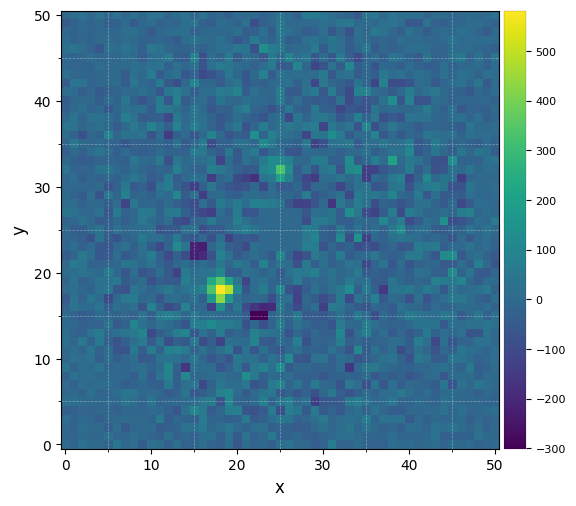

In [90]:
# Full frame PCA
inner_rad_adi = 3 #lam/D

pca1 = pca(np.array([coadd_roll1, coadd_roll2]), np.array(cistar_coadd_ep1_rolls), cube_ref=None, ncomp=1, 
           svd_mode='lapack', mask_center_px=inner_rad_adi, full_output=False)

plot_frames(pca1, grid=True)#, backend='bokeh')

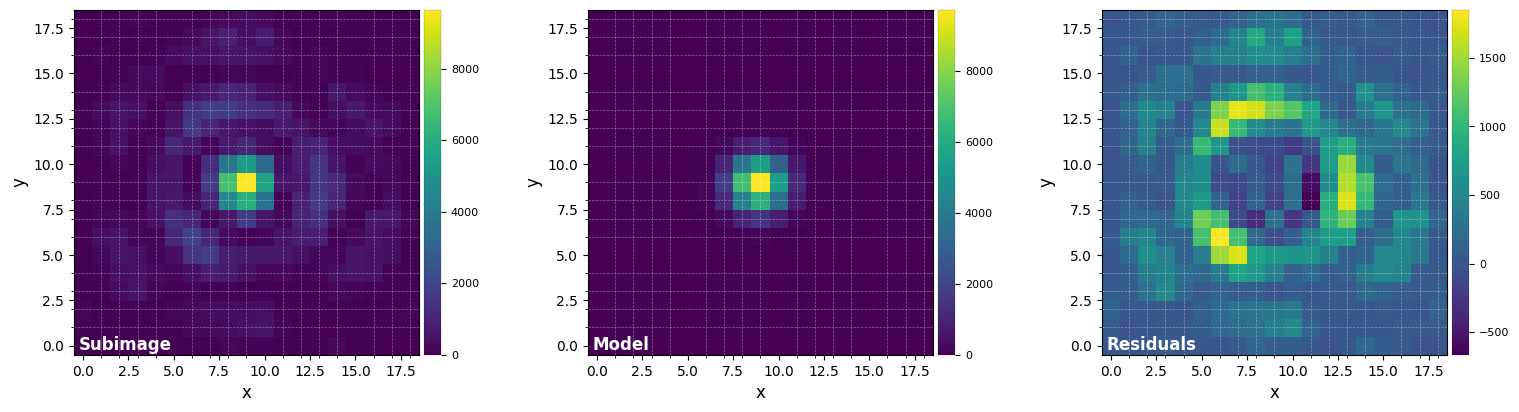

FWHM_y = 2.3292790904211556
FWHM_x = 2.4068262439159147 

centroid y = 8.927418940843133
centroid x = 8.885117219881993
centroid y subim = 8.927418940843133
centroid x subim = 8.885117219881993 

amplitude = 9813.079504365174
theta = -5.116814898554604

Mean FWHM: 2.368
Flux in 1xFWHM aperture: 28339.960


In [91]:
from vip_hci.fm import normalize_psf  # fm is the forward modeling subpackage, with various tools for the characterization of point sources and extended signals.

psfn, flux, fwhm_naco = normalize_psf(host_star_PSF, size=19, debug=True, full_output=True)

Blobs found: 1
 ycen   xcen
------ ------
18.010 	 18.097

――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――
X,Y = (18.1,18.0)
――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――
Coords of chosen px (X,Y) = 18.1, 18.0
Flux in a centered 1xFWHM circular aperture = 3168.957
Central pixel S/N = 7.225
――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――
Inside a centered 1xFWHM circular aperture:
Mean S/N (shifting the aperture center) = 6.026
Max S/N (shifting the aperture center) = 8.194
stddev S/N (shifting the aperture center) = 1.676

――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――


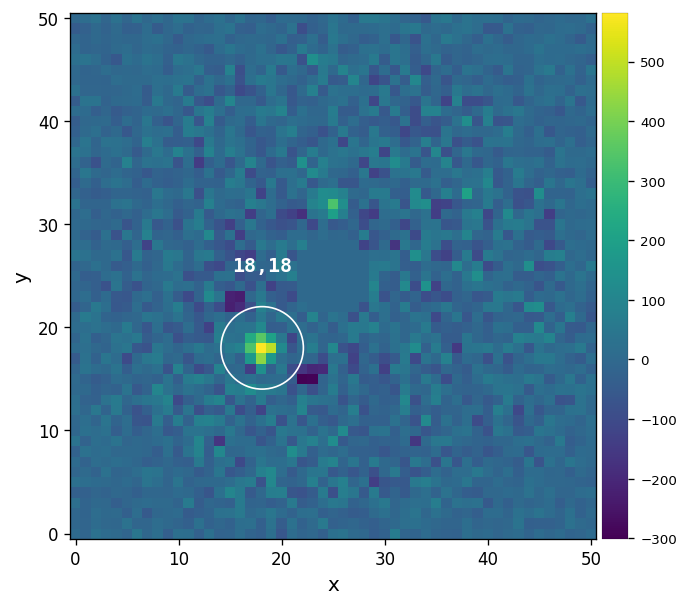

(array([18.00956843]), array([18.09659151]))

In [ ]:
vip_hci.metrics.detection(pca1, psf=psfn, debug=False,mode='log', snr_thresh=3, 
                      bkg_sigma=4, matched_filter=False)

In [98]:
from vip_hci.metrics import snr
xy_b = (25,32)
snr1 = snr(pca1, source_xy=xy_b, fwhm=fwhm_naco)
print(r"S/N = {:.1f}".format(snr1))

S/N = 6.5


――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――
Starting time: 2026-03-08 18:19:05
――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――


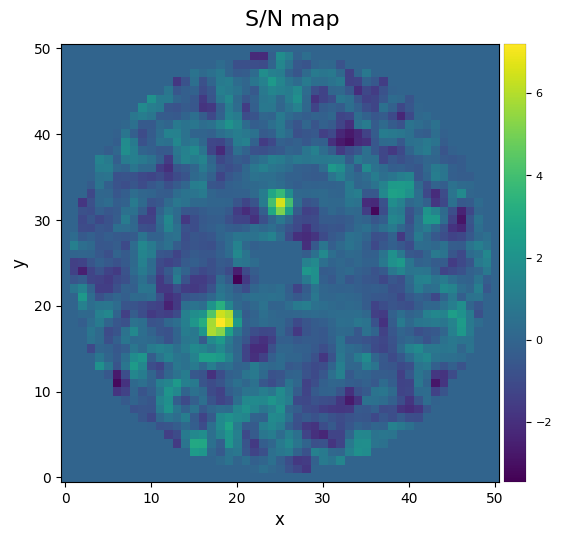

S/N map created using 5 processes
Running time:  0:00:00.569422
――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――


In [100]:
from vip_hci.metrics import snrmap

snrmap1 = snrmap(pca1, fwhm_naco, plot=True)

――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――
Starting time: 2026-03-08 18:30:43
――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――
System total memory = 38.655 GB
System available memory = 12.835 GB
Done vectorizing the frames. Matrix shape: (2, 2601)
Done SVD/PCA with numpy SVD (LAPACK)
Running time:  0:00:00.001626
――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――
Done de-rotating and combining
Running time:  0:00:00.012364
――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――


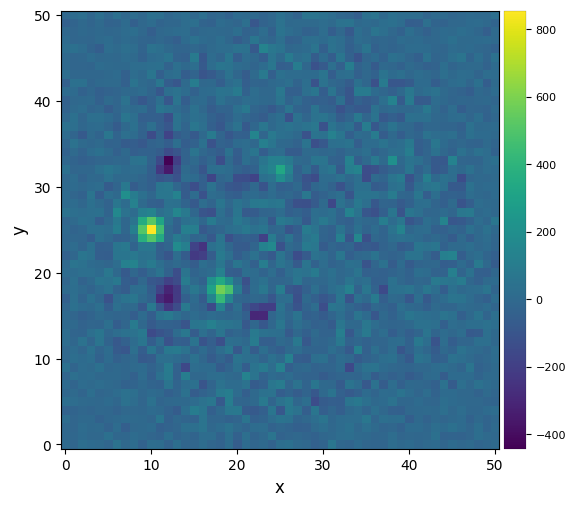

In [110]:
## Make fake planets
from vip_hci.fm import cube_inject_companions 

imlib_rot = 'skimage'      # If you have opencv installed, feel free to set this parameter to" 'opencv'
interpolation= 'biquintic'   # If you have opencv installed, feel free to set this parameter to 'lanczos4'

pxscale=0.0210804
blank=np.zeros(((2,45,45)))
cubefc2 = cube_inject_companions(blank, psfn, np.array(cistar_coadd_ep1_rolls), flevel=561, plsc=pxscale, 
                                rad_dists=[15], theta=180, n_branches=1)

cubefc = cube_inject_companions(np.array([coadd_roll1, coadd_roll2]), psfn, np.array(cistar_coadd_ep1_rolls), flevel=5000, plsc=pxscale, 
                                rad_dists=[15], theta=180, n_branches=1)
pca1_fc = pca(cubefc, np.array(cistar_coadd_ep1_rolls), ncomp=1)

plot_frames(pca1_fc)
                                 

――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――
Starting time: 2026-03-08 18:36:34
――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――

――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――
             Planet 0           
――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――

Planet 0: flux estimation at the position [18,18], running ...
Step | flux    | chi2r
1/30   0.100   0.984
2/30   0.149   0.984
3/30   0.221   0.984
4/30   0.329   0.984
5/30   0.489   0.984
6/30   0.728   0.984
7/30   1.083   0.984
8/30   1.610   0.984
9/30   2.395   0.983
10/30   3.562   0.983
11/30   5.298   0.982
12/30   7.880   0.981
13/30   11.721   0.979
14/30   17.433   0.977
15/30   25.929   0.973
16/30   38.566   0.967
17/30   57.362   0.959
18/30   85.317   0.947
19/30   126.896   0.929
20/30   188.739   0.903
21/30   280.722   0.865
22/30   417.532   0.810
23/30   621.017   0.732
24/30  

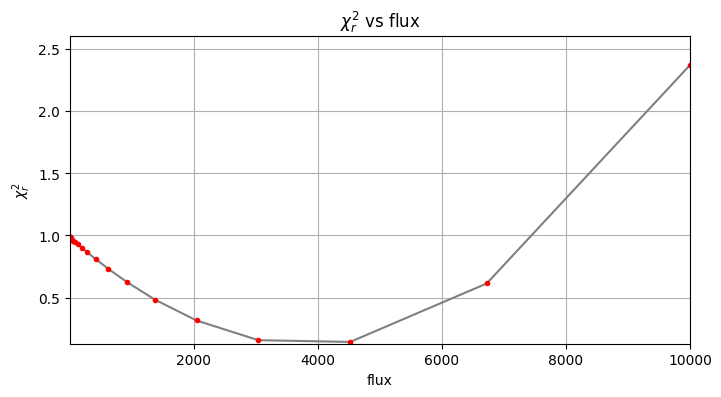

Planet 0: preliminary position guess: (r, theta)=(9.9, 225.0)
Planet 0: preliminary flux guess: 4520.35
Planet 0: Simplex Nelder-Mead minimization, running ...
Planet 0: Success: True, nit: 118, nfev: 234, chi2r: 0.0970229287486889
message: Optimization terminated successfully.
Planet 0 simplex result: (r, theta, f)=(9.764, 225.788, 3910.131) at 
          (X,Y)=(18.19, 18.00)

 ―――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――― 
DONE !
 ――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――
Running time:  0:00:00.545357
――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――


In [115]:
from vip_hci.fm import firstguess

source_xy = (18,18)
ncomp_fc = 1
fwhm = 2.5

r_0, theta_0, f_0 = firstguess(np.array([coadd_roll1, coadd_roll2]), np.array(cistar_coadd_ep1_rolls), psfn, ncomp=ncomp_fc, planets_xy_coord=[source_xy], 
                                  fwhm=fwhm, f_range=None, annulus_width=4*fwhm, 
                                  aperture_radius=2, simplex=True, imlib=imlib_rot, 
                                  interpolation=interpolation, plot=True, verbose=True)

In [116]:
print(r_0, theta_0, f_0)

[9.76384018] [225.78795562] [3910.13146018]


――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――
Starting time: 2026-03-08 18:43:54
――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――
        MCMC sampler for the NEGFC technique       
――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――
The mean and stddev in the annulus at the radius of the companion (excluding the PA area directly adjacent to it) are 0.04 and 137.80 respectively.
Beginning emcee Ensemble sampler...
emcee Ensemble sampler successful

Start of the MCMC run ...
Step  |  Duration/step (sec)  |  Remaining Estimated Time (sec)
0		0.99489			496.45111
1		0.06454			32.14042
2		0.05806			28.85433
3		0.05647			28.00664
4		0.05768			28.55308
5		0.06434			31.78544
6		0.05583			27.52616
7		0.05642			27.75716
8		0.05614			27.56376
9		0.05659			27.73057
10		0.05575			27.26028
11		0.05652			27.58322
12		0.05584			27.19359
13		0.05699			27.69908
14		0.05658			27.44081
15		0.05671			27.44619
16

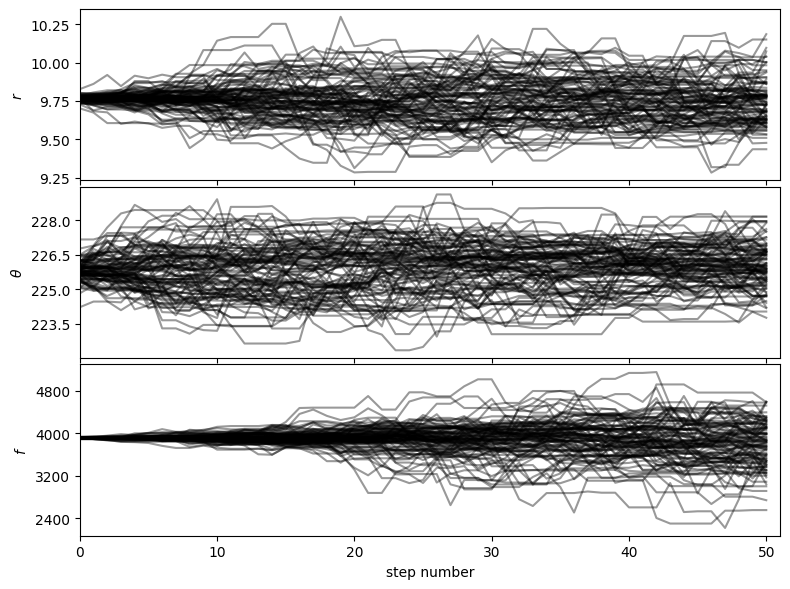

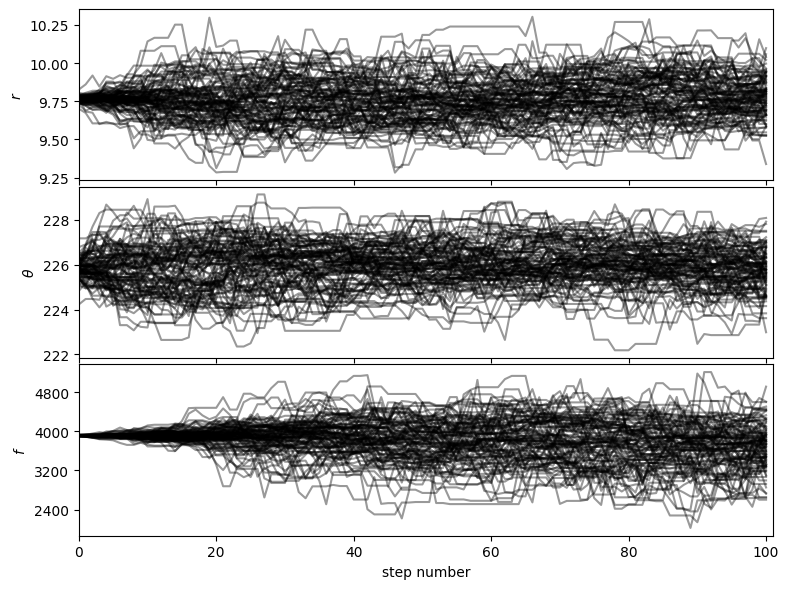

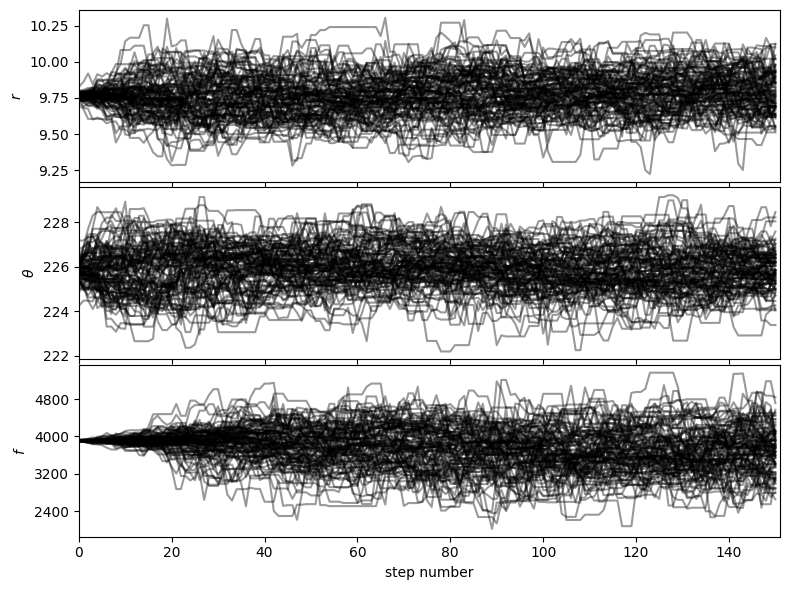

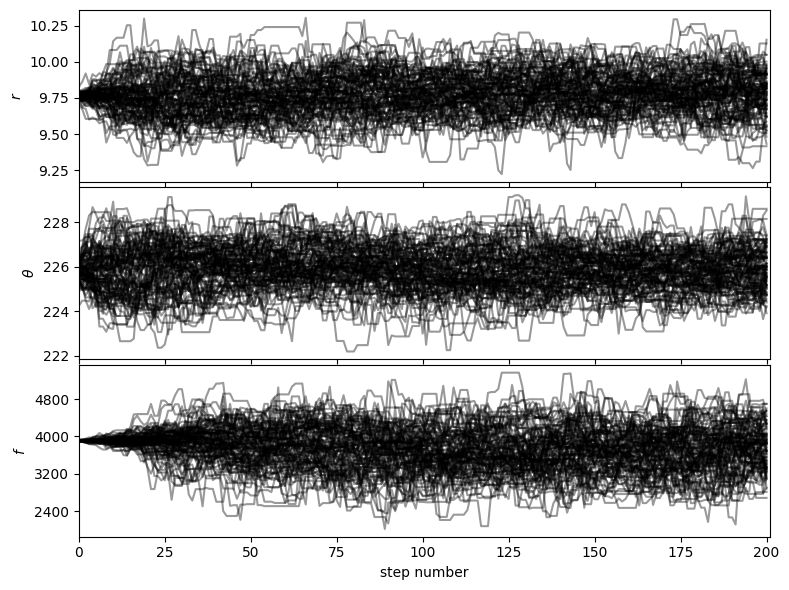

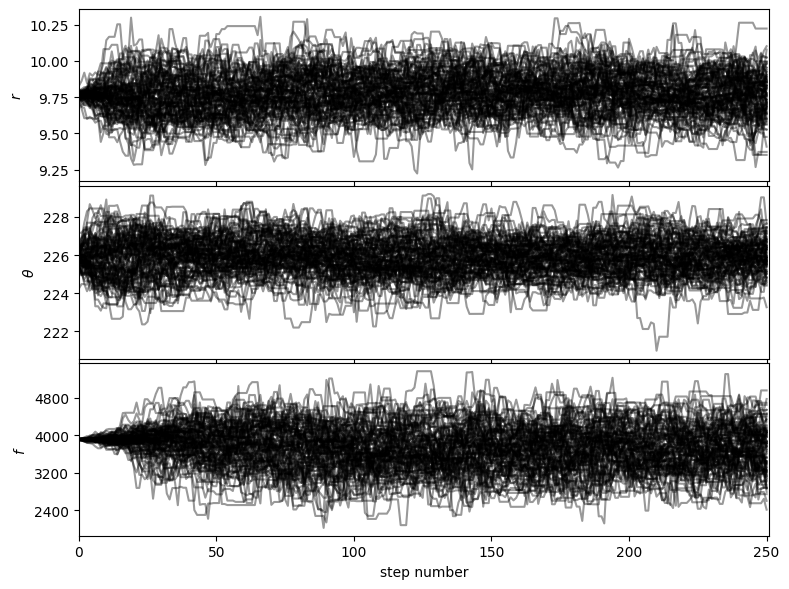

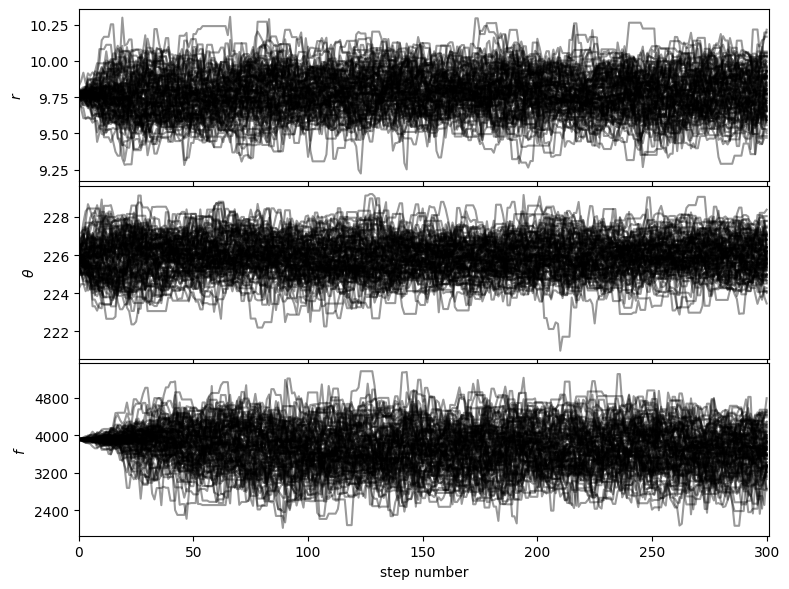

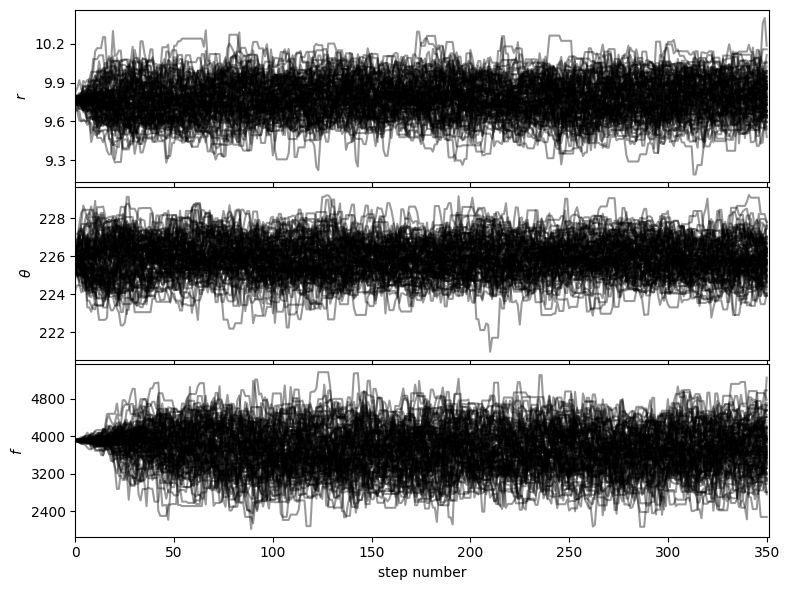

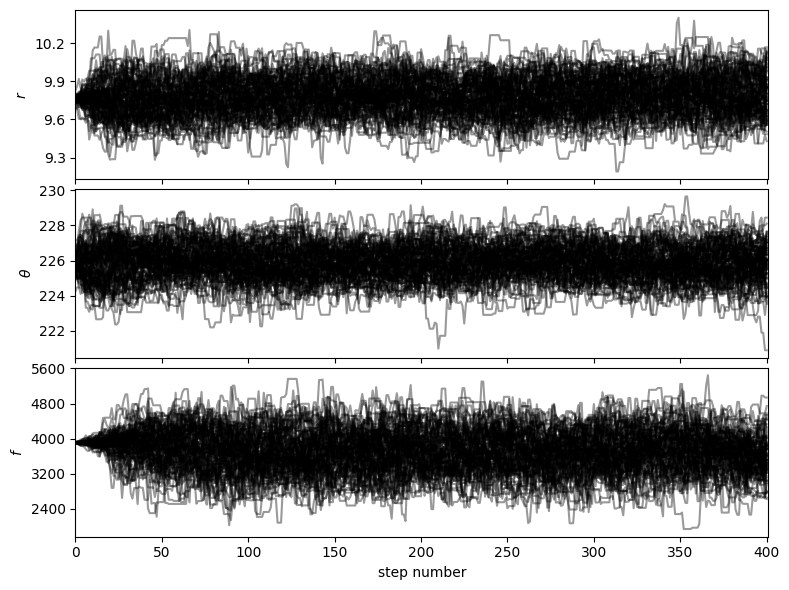

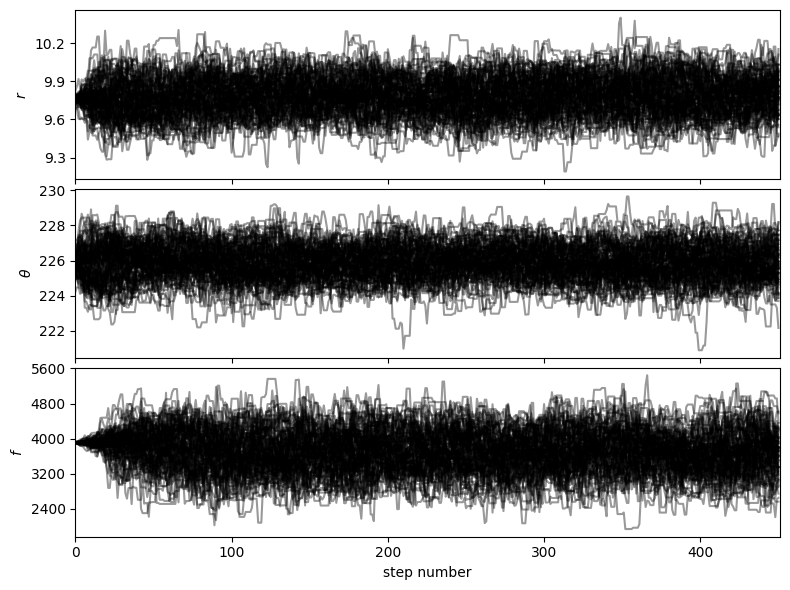

In [117]:
from vip_hci.psfsub import pca_annulus

obs_params = {'psfn': psfn,
              'fwhm': fwhm}
annulus_width = 4*fwhm

algo_params = {'algo': pca_annulus,
               'ncomp': 1,
               'annulus_width': annulus_width,
               'svd_mode': 'lapack',
               'imlib': imlib_rot, 
               'interpolation': interpolation}

mu_sigma=True
aperture_radius=2

negfc_params = {'mu_sigma': mu_sigma,
                'aperture_radius': aperture_radius}

initial_state = np.array([r_0[0], theta_0[0], f_0[0]])

from multiprocessing import cpu_count

nwalkers, itermin, itermax = (100, 200, 500)

mcmc_params = {'nwalkers': nwalkers,
               'niteration_min': itermin,
               'niteration_limit': itermax,
               'bounds': None,
               'nproc': cpu_count()//2}

conv_test, ac_c, ac_count_thr, check_maxgap = ('ac', 50, 1, 50)

conv_params = {'conv_test': conv_test,
               'ac_c': ac_c,
               'ac_count_thr': ac_count_thr,
               'check_maxgap': check_maxgap}

from vip_hci.fm import mcmc_negfc_sampling
chain = mcmc_negfc_sampling(cubefc, np.array(cistar_coadd_ep1_rolls), **obs_params, **algo_params, **negfc_params, 
                            initial_state=initial_state, **mcmc_params, **conv_params,
                            display=True, verbosity=2, save=False, output_dir='./')

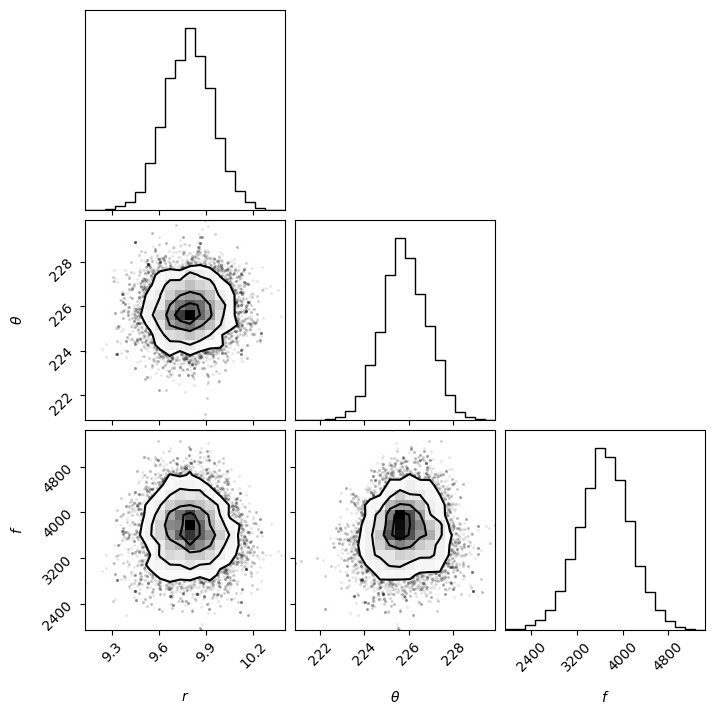

In [119]:
from vip_hci.fm import show_corner_plot
burnin = 0.3
burned_chain = chain[:, int(chain.shape[1]//(1/burnin)):, :]
show_corner_plot(burned_chain)